In [29]:
# API key:     2f710d1cfe0e44cec6d8a7c8efb755fe
import os
import warnings

import numpy as np
import pandas as pd
import xarray
from datetime import datetime
import cftime
import matplotlib.pyplot as plt
from matplotlib import colors
#import imageio.v2 as imageio
#from IPython.display import Video
#from tqdm import trange
#from pymt.models import Topography
from bmi_topography import Topography
from landlab import RasterModelGrid

In [30]:
lat, lon = (61.381966, -148.751816)  # Bennett Valley
#left side -148.774816
y= -148.774816+148.751816
print(y)
height, width = 0.023, 0.023

longs_peak_dem = Topography(
    north=lat + height,
    south=lat - height,
    east=lon + width,
    west=lon - width,
    output_format='GTiff',
    dem_type="SRTMGL3",
    api_key='2f710d1cfe0e44cec6d8a7c8efb755fe',
)
longs_peak = longs_peak_dem.load()
print(f"Shape of the data = {longs_peak.values.shape}")
print(f"Minimum elevation = {longs_peak.values.min()}")
print(f"Maximum elevation = {longs_peak.values.max()}")

-0.022999999999996135


RasterioIOError: '/home/jupyter-keyahopwood@gmail.-35e30/.bmi_topography/SRTMGL3_61.358965999999995_-148.774816_61.404966_-148.728816.tif' not recognized as being in a supported file format.

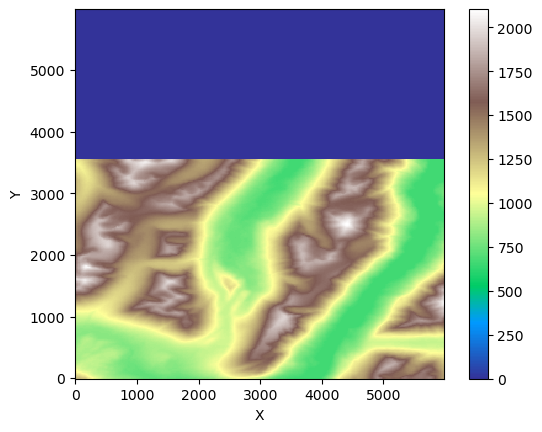

In [22]:
z = np.flipud(longs_peak.values.squeeze())
grid = RasterModelGrid(z.shape, xy_spacing=(20.0, 20.0))
grid.at_node["topographic__elevation"] = z
grid.imshow("topographic__elevation", cmap="terrain", vmin=0)